In [1]:
!pip install -q torchinfo

# Quantization and Export Libraries for Ethos U55

# https://github.com/google-ai-edge/litert-torch
!pip install -q litert_torch

# https://github.com/google-ai-edge/ai-edge-quantizer
# specific post quantize trainer for litert models
!pip install -q ai-edge-quantizer-nightly

# For Ethos NPUs
!pip install -q ethos-u-vela

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.8/575.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.3/419.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 30.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openai 2.37.0 requires typing

In [3]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image

In [4]:
TARGET_SIZE = "l"

FOMO_CONFIGS = {
    "s": {"ckpt": "LibreFOMOs.pt", "imgsz": 96},
    "m": {"ckpt": "LibreFOMOm.pt", "imgsz": 192},
    "l": {"ckpt": "LibreFOMOl.pt", "imgsz": 224},
}


ACTIVE_CKPT = FOMO_CONFIGS[TARGET_SIZE]["ckpt"]
ACTIVE_IMG_SIZE = FOMO_CONFIGS[TARGET_SIZE]["imgsz"]

FOMO_DOWNSAMPLE_FACTOR = 8 # LibreFOMO reduces resolution by 8x
ACTIVE_GRID_SIZE = ACTIVE_IMG_SIZE // FOMO_DOWNSAMPLE_FACTOR
# s: 12
# m: 24
# l: 28

print(f"Configuring pipeline for size '{TARGET_SIZE}' | Checkpoint: {ACTIVE_CKPT}")
print(f"Resolution: {ACTIVE_IMG_SIZE}x{ACTIVE_IMG_SIZE} | Target Grid: {ACTIVE_GRID_SIZE}x{ACTIVE_GRID_SIZE}")

Configuring pipeline for size 'l' | Checkpoint: LibreFOMOl.pt
Resolution: 224x224 | Target Grid: 28x28


In [5]:
from huggingface_hub import hf_hub_download
import importlib.util
import torch
import urllib.request
from pathlib import Path

repo_id = "bdanko/LibreFOMO"
github_url = "https://raw.githubusercontent.com/bencejdanko/librefomo-preparation-and-training/refs/heads/main/model.py"
model_py_path = Path("model.py")

try:
    print(f"Downloading model.py from GitHub: {github_url}")
    urllib.request.urlretrieve(github_url, model_py_path)
    model_py = str(model_py_path.resolve())
    print("Successfully downloaded model.py from GitHub.")
except Exception as e:
    print(f"Failed to download from GitHub: {e}. Falling back to Hugging Face...")
    model_py = hf_hub_download(repo_id=repo_id, filename="model.py")

ckpt_path = hf_hub_download(repo_id=repo_id, filename=ACTIVE_CKPT)

# Import the downloaded model.py
spec = importlib.util.spec_from_file_location("librefomo_model", model_py)
librefomo_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(librefomo_model)

# Load checkpoint
model, ckpt = librefomo_model.load_librefomo_checkpoint(ckpt_path, map_location="cuda:0")

Successfully downloaded model.py from GitHub.


LibreFOMOl.pt:   0%|          | 0.00/302k [00:00<?, ?B/s]

In [6]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, ACTIVE_IMG_SIZE, ACTIVE_IMG_SIZE),
    col_names=(
        "input_size",
        "output_size",
        "num_params",
        "kernel_size",
    ),
)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Kernel Shape
LibreFOMO                                               [1, 3, 224, 224]          [1, 2, 28, 28]            --                        --
├─LibreFOMOBackbone: 1-1                                [1, 3, 224, 224]          [1, 192, 28, 28]          --                        --
│    └─ConvBNReLU6: 2-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         --                        --
│    │    └─StaticSamePadConv2d: 3-1                    [1, 3, 224, 224]          [1, 32, 112, 112]         864                       [3, 3]
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         [1, 32, 112, 112]         64                        --
│    │    └─ReLU6: 3-3                                  [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
│    └─InvertedResidual: 2-

In [7]:
class FOMODataset(Dataset):
    def __init__(self, hf_dataset, input_size=192, grid_size=24, original_res=512):
        self.hf_dataset = hf_dataset
        self.input_size = input_size
        self.grid_size = grid_size
        self.original_res = original_res

        self.image_transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'].convert("RGB")
        img_tensor = self.image_transform(image)

        target_grid = torch.zeros((self.grid_size, self.grid_size), dtype=torch.long)

        # Scale factors
        scale_x = self.input_size / self.original_res
        scale_y = self.input_size / self.original_res

        if 'objects' in item and 'bbox' in item['objects']:
            for bbox in item['objects']['bbox']:
                x, y, w, h = bbox

                cx_orig = x + (w / 2.0)
                cy_orig = y + (h / 2.0)

                # Scale coordinates instead of shifting
                cx_resized = cx_orig * scale_x
                cy_resized = cy_orig * scale_y

                if 0 <= cx_resized < self.input_size and 0 <= cy_resized < self.input_size:
                    grid_x = int((cx_resized / self.input_size) * self.grid_size)
                    grid_y = int((cy_resized / self.input_size) * self.grid_size)

                    # Ensure indices are within bounds
                    grid_x = min(max(grid_x, 0), self.grid_size - 1)
                    grid_y = min(max(grid_y, 0), self.grid_size - 1)

                    target_grid[grid_y, grid_x] = 1

        return img_tensor, target_grid

# Load your dataset
print("Loading dataset from HF...")
hf_train = load_dataset("bdanko/loaf_resolution_512", split="train")
hf_val = load_dataset("bdanko/loaf_resolution_512", split="validation")

train_dataset = FOMODataset(hf_train, input_size=ACTIVE_IMG_SIZE, grid_size=ACTIVE_GRID_SIZE)
val_dataset = FOMODataset(hf_val, input_size=ACTIVE_IMG_SIZE, grid_size=ACTIVE_GRID_SIZE)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Loading dataset from HF...


README.md:   0%|          | 0.00/4.27k [00:00<?, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/518M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/546M [00:00<?, ?B/s]

...

data/test-00001-of-00003.parquet:   0%|          | 0.00/373M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/402M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29569 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8773 [00:00<?, ? examples/s]

In [8]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Weight for [Background, Person].
class_weights = torch.tensor([1.0, 100.0], dtype=torch.float).to(device)

# CrossEntropyLoss naturally accepts inputs of (B, C, H, W) and targets of (B, H, W)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler (Mirroring your TF setup)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

In [ ]:
# POINT VALIDATION
# To properly evaluate a point-based model,
# we must match predicted centroids to ground truth centroids.
# Because grid cells are discrete, slight offsets should not be
# penalized as false positives if they are sufficiently close.

# Hungarian Algorithm for optimal bipartite matching.
# Ensures one predicted point matches to exactly
# one ground truth point,
# minimizing the total distance error across the batch.

$$Precision = \frac{TP}{TP + FP}$$$$Recall = \frac{TP}{TP + FN}$$$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [9]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

def decode_points_from_logits(
    pred_logits,
    conf_threshold=0.5,
    nms_radius=1,
    max_points=None,
):
    """
    Converts FOMO logits into point detections.

    nms_radius=1 suppresses a 3x3 neighborhood around each selected peak.
    Use radius=0 to reproduce raw thresholding, or radius=2 for stronger de-blobing.
    """
    probs = F.softmax(pred_logits, dim=1)[:, 1]  # B,H,W
    batch_points = []

    B, H, W = probs.shape
    for b in range(B):
        prob = probs[b]
        ys, xs = torch.where(prob >= conf_threshold)

        if ys.numel() == 0:
            batch_points.append(np.zeros((0, 3), dtype=np.float32))
            continue

        scores = prob[ys, xs]
        order = torch.argsort(scores, descending=True)

        suppressed = torch.zeros((H, W), dtype=torch.bool, device=prob.device)
        kept = []

        for idx in order:
            y = int(ys[idx])
            x = int(xs[idx])

            if suppressed[y, x]:
                continue

            kept.append((x, y, float(scores[idx])))

            y0 = max(0, y - nms_radius)
            y1 = min(H, y + nms_radius + 1)
            x0 = max(0, x - nms_radius)
            x1 = min(W, x + nms_radius + 1)
            suppressed[y0:y1, x0:x1] = True

            if max_points is not None and len(kept) >= max_points:
                break

        batch_points.append(np.array(kept, dtype=np.float32))

    return batch_points


def calculate_point_metrics(
    pred_logits,
    targets,
    conf_threshold=0.5,
    distance_tolerance=1.5,
    nms_radius=1,
):
    """
    Returns TP, FP, FN, and total matched distance.
    Distance tolerance is in output-grid cells.
    """
    decoded = decode_points_from_logits(
        pred_logits,
        conf_threshold=conf_threshold,
        nms_radius=nms_radius,
    )

    total_tp, total_fp, total_fn = 0, 0, 0
    total_distance = 0.0

    for b, preds_with_scores in enumerate(decoded):
        preds = preds_with_scores[:, :2] if len(preds_with_scores) else np.zeros((0, 2))

        true_y, true_x = torch.where(targets[b] == 1)
        trues = torch.stack((true_x, true_y), dim=1).cpu().numpy()

        if len(preds) == 0 and len(trues) == 0:
            continue
        if len(preds) == 0:
            total_fn += len(trues)
            continue
        if len(trues) == 0:
            total_fp += len(preds)
            continue

        dist_matrix = cdist(preds, trues)
        row_ind, col_ind = linear_sum_assignment(dist_matrix)

        matched_preds = set()
        matched_trues = set()

        for r, c in zip(row_ind, col_ind):
            dist = dist_matrix[r, c]
            if dist <= distance_tolerance:
                total_tp += 1
                total_distance += dist
                matched_preds.add(r)
                matched_trues.add(c)

        total_fp += len(preds) - len(matched_preds)
        total_fn += len(trues) - len(matched_trues)

    return total_tp, total_fp, total_fn, total_distance

In [10]:
def prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1


def evaluate_sweep(
    model,
    val_loader,
    criterion,
    device,
    conf_thresholds=(0.25, 0.35, 0.50, 0.65, 0.80, 0.90),
    nms_radii=(1, 2),
    distance_tolerance=1.5,
):
    model.eval()

    cached_outputs = []
    val_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)

            if logits.shape[-2:] != targets.shape[-2:]:
                raise ValueError(
                    f"Model output grid {logits.shape[-2:]} does not match "
                    f"target grid {targets.shape[-2:]}"
                )

            loss = criterion(logits, targets)
            val_loss += loss.item()

            cached_outputs.append((logits.cpu(), targets.cpu()))

    avg_val_loss = val_loss / len(val_loader)

    all_results = []
    best = None

    for threshold in conf_thresholds:
        for nms_radius in nms_radii:
            total_tp = 0
            total_fp = 0
            total_fn = 0
            total_dist = 0.0

            for logits_cpu, targets_cpu in cached_outputs:
                tp, fp, fn, dist = calculate_point_metrics(
                    logits_cpu,
                    targets_cpu,
                    conf_threshold=threshold,
                    distance_tolerance=distance_tolerance,
                    nms_radius=nms_radius,
                )

                total_tp += tp
                total_fp += fp
                total_fn += fn
                total_dist += dist

            precision, recall, f1 = prf(total_tp, total_fp, total_fn)
            mean_dist = total_dist / max(total_tp, 1)

            result = {
                "threshold": float(threshold),
                "nms_radius": int(nms_radius),
                "distance_tolerance": float(distance_tolerance),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "mean_dist": mean_dist,
                "tp": total_tp,
                "fp": total_fp,
                "fn": total_fn,
            }

            all_results.append(result)

            if best is None or result["f1"] > best["f1"]:
                best = result

    return avg_val_loss, best, all_results

In [11]:
import copy
import torch
from tqdm import tqdm

epochs = 40
best_f1_score = 0.0
best_ckpt_path = "LibreFOMO_finetuned.pt"

# This will be filled when the first best model is saved.
best_decode_config = None

for epoch in range(epochs):

    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_loss = 0.0

    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs} [Train]"
    )

    for images, targets in train_pbar:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}"
        })

    avg_train_loss = train_loss / len(train_loader)

    # -------------------------
    # Validate with threshold/NMS sweep
    # -------------------------
    avg_val_loss, best_epoch_result, sweep_results = evaluate_sweep(
        model=model,
        val_loader=val_loader,
        criterion=criterion,
        device=device,
        conf_thresholds=(0.25, 0.35, 0.50, 0.65, 0.80, 0.90),
        nms_radii=(1, 2),
        distance_tolerance=1.5,
    )

    precision = best_epoch_result["precision"]
    recall = best_epoch_result["recall"]
    f1_score = best_epoch_result["f1"]
    mean_dist = best_epoch_result["mean_dist"]

    selected_threshold = best_epoch_result["threshold"]
    selected_nms_radius = best_epoch_result["nms_radius"]
    selected_distance_tolerance = best_epoch_result["distance_tolerance"]

    # Your scheduler is mode="max", so step it with F1.
    scheduler.step(f1_score)
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"--> Summary | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Best F1: {f1_score:.4f} | "
        f"Prec: {precision:.4f} | "
        f"Rec: {recall:.4f} | "
        f"MeanDist: {mean_dist:.3f} | "
        f"Thresh: {selected_threshold:.2f} | "
        f"NMS: {selected_nms_radius} | "
        f"LR: {current_lr:.6f}"
    )

    # Optional but helpful: print the top few sweep results so you can see
    # whether threshold/NMS choice is stable or bouncing around.
    top_results = sorted(
        sweep_results,
        key=lambda r: r["f1"],
        reverse=True
    )[:3]

    print("--> Top validation settings:")
    for r in top_results:
        print(
            f"    F1={r['f1']:.4f} | "
            f"P={r['precision']:.4f} | "
            f"R={r['recall']:.4f} | "
            f"Thresh={r['threshold']:.2f} | "
            f"NMS={r['nms_radius']} | "
            f"TP={r['tp']} FP={r['fp']} FN={r['fn']}"
        )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if f1_score > best_f1_score:
        best_f1_score = f1_score

        best_decode_config = {
            "threshold": selected_threshold,
            "nms_radius": selected_nms_radius,
            "distance_tolerance": selected_distance_tolerance,
        }

        print(
            f"--> Saving new best model | "
            f"F1: {best_f1_score:.4f} | "
            f"threshold: {best_decode_config['threshold']:.2f} | "
            f"nms: {best_decode_config['nms_radius']}"
        )

        save_ckpt = copy.deepcopy(ckpt)
        save_ckpt["model"] = model.state_dict()
        save_ckpt["decode_config"] = best_decode_config
        save_ckpt["best_f1_score"] = best_f1_score
        save_ckpt["best_epoch"] = epoch + 1
        save_ckpt["best_epoch_result"] = best_epoch_result

        torch.save(save_ckpt, best_ckpt_path)

Epoch 1/40 [Train]: 100%|██████████| 925/925 [00:59<00:00, 15.62it/s, batch_loss=0.2728]


--> Summary | Train Loss: 0.1738 | Val Loss: 0.2551 | Best F1: 0.4524 | Prec: 0.3762 | Rec: 0.5673 | MeanDist: 0.421 | Thresh: 0.90 | NMS: 1 | LR: 0.000300
--> Top validation settings:
    F1=0.4524 | P=0.3762 | R=0.5673 | Thresh=0.90 | NMS=1 | TP=23624 FP=39170 FN=18022
    F1=0.4383 | P=0.3316 | R=0.6463 | Thresh=0.80 | NMS=1 | TP=26915 FP=54256 FN=14731
    F1=0.4161 | P=0.3913 | R=0.4443 | Thresh=0.90 | NMS=2 | TP=18503 FP=28778 FN=23143
--> Saving new best model | F1: 0.4524 | threshold: 0.90 | nms: 1


Epoch 2/40 [Train]:  76%|███████▋  | 706/925 [00:45<00:14, 15.64it/s, batch_loss=0.1161]


KeyboardInterrupt: 

In [12]:
# Load best checkpoint for evaluation / visualization.
best_ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(best_ckpt["model"])
model = model.to(device)
model.eval()

decode_config = best_ckpt.get("decode_config", {
    "threshold": 0.5,
    "nms_radius": 1,
    "distance_tolerance": 1.5,
})

print("Loaded best checkpoint:")
print(f"  best_f1_score: {best_ckpt.get('best_f1_score', 'unknown')}")
print(f"  best_epoch: {best_ckpt.get('best_epoch', 'unknown')}")
print(f"  decode_config: {decode_config}")

Loaded best checkpoint:
  best_f1_score: 0.4523937188816545
  best_epoch: 1
  decode_config: {'threshold': 0.9, 'nms_radius': 1, 'distance_tolerance': 1.5}


In [13]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F

def visualize_fomo_predictions(
    model,
    dataloader,
    device,
    threshold=0.5,
    nms_radius=1,
    num_samples=4,
):
    model.eval()

    dataset = dataloader.dataset


    actual_samples = min(num_samples, len(dataset))
    random_indices = random.sample(range(len(dataset)), actual_samples)

    images_list, targets_list = [], []
    for idx in random_indices:
        img, tgt = dataset[idx]
        images_list.append(img)
        targets_list.append(tgt)

    # Stack them into tensors (B, C, H, W) and (B, H, W)
    images = torch.stack(images_list).to(device)
    targets = torch.stack(targets_list).to(device)

    with torch.no_grad():
        logits = model(images)

    decoded = decode_points_from_logits(
        logits.cpu(),
        conf_threshold=threshold,
        nms_radius=nms_radius,
    )

    images = images.cpu()
    targets = targets.cpu()

    fig, axes = plt.subplots(actual_samples, 2, figsize=(8, 4 * actual_samples))

    grid_size = targets.shape[-1]
    input_size = images.shape[-1]
    scale = input_size / grid_size

    for i in range(actual_samples):
        img_display = images[i].permute(1, 2, 0).numpy()
        img_display = (img_display * 0.5) + 0.5
        img_display = np.clip(img_display, 0, 1)

        ax_true = axes[i, 0] if actual_samples > 1 else axes[0]
        ax_true.imshow(img_display)
        ax_true.set_title("Ground Truth")
        ax_true.axis("off")

        true_y, true_x = torch.where(targets[i] == 1)

        for ty, tx in zip(true_y, true_x):
            ax_true.plot(
                (tx + 0.5) * scale,
                (ty + 0.5) * scale,
                "ro",
                markersize=8,
            )

        ax_pred = axes[i, 1] if actual_samples > 1 else axes[1]
        ax_pred.imshow(img_display)
        ax_pred.set_title(f"Decoded Predictions | t={threshold}, nms={nms_radius}")
        ax_pred.axis("off")

        for px, py, score in decoded[i]:
            ax_pred.plot(
                (px + 0.5) * scale,
                (py + 0.5) * scale,
                "go",
                markersize=8,
            )
            ax_pred.text(
                (px + 0.5) * scale + 2,
                (py + 0.5) * scale,
                f"{score:.2f}",
                color="white",
                fontsize=9,
            )

    plt.tight_layout()
    plt.show()

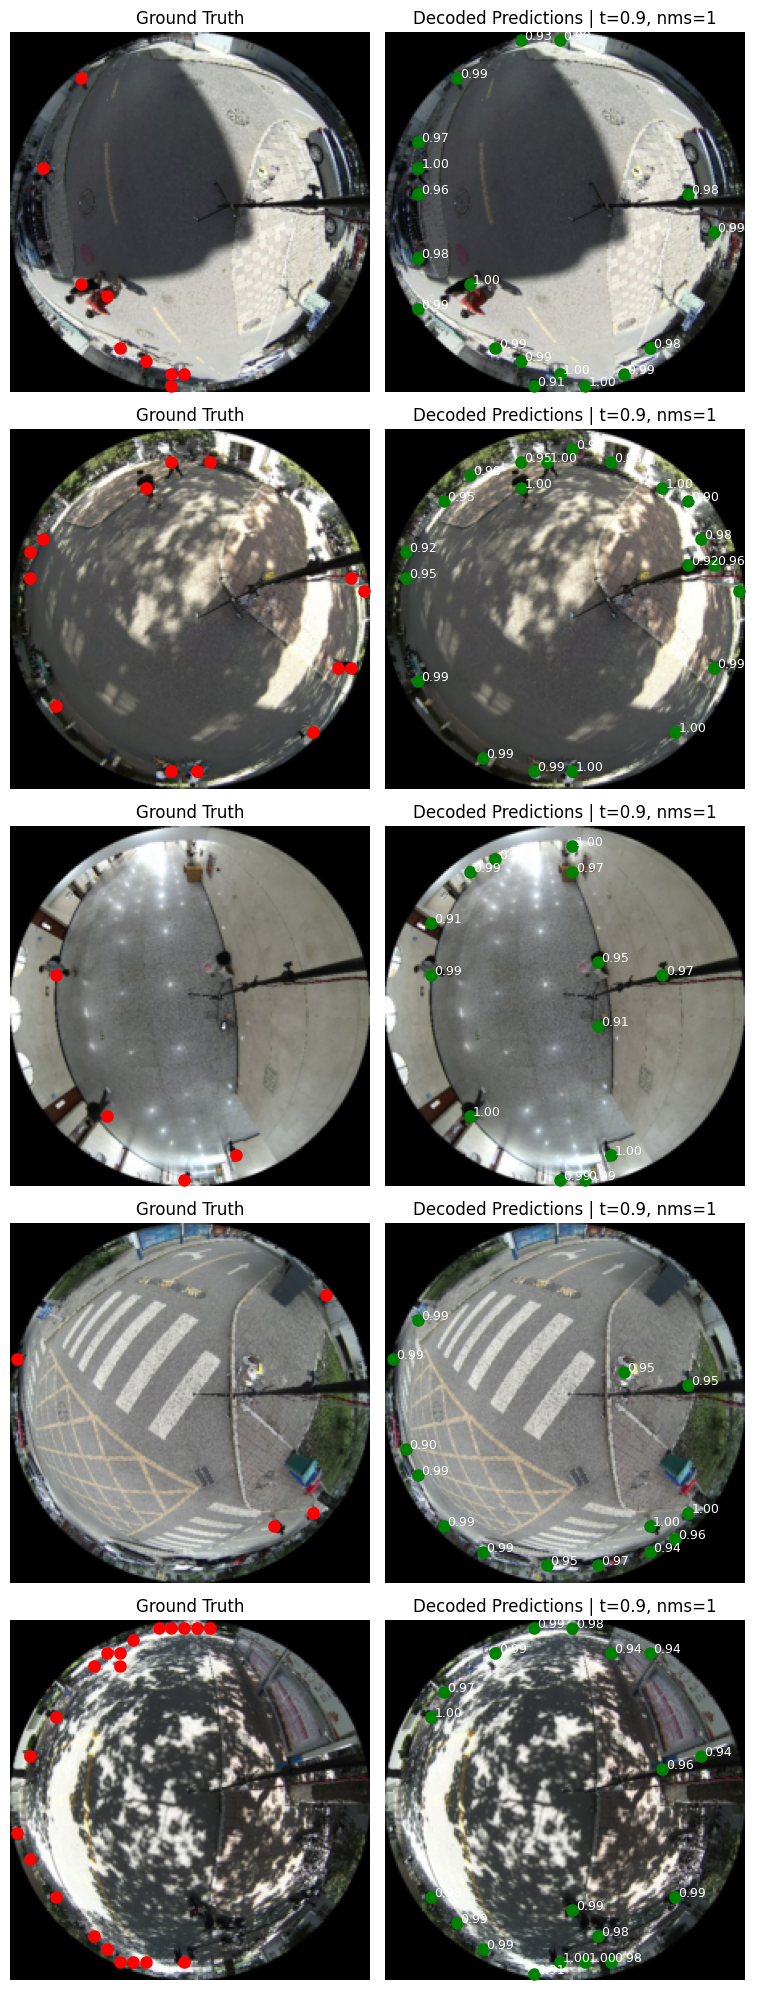

In [14]:
visualize_fomo_predictions(
    model,
    val_loader,
    device,
    threshold=decode_config["threshold"],
    nms_radius=decode_config["nms_radius"],
    num_samples=5,
)

In [15]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
ai-edge-litert==2.1.5
ai-edge-litert-nightly==2.2.0.dev20260531
ai-edge-quantizer==0.7.0
ai-edge-quantizer-nightly==0.8.0.dev20260601
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.5.18.1.11.28
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
backports.strenum==1.2.8
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.40.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2=

In [16]:
import litert_torch
import torch

# PyTorch model to LiteRT FP32

# Move the model to CPU and set to evaluation mode
model.cpu()
model.eval()

# Create a dummy input matching expected input dimensions
sample_input = torch.randn(1, 3, ACTIVE_IMG_SIZE, ACTIVE_IMG_SIZE)

# Convert and export the flatbuffer
edge_model = litert_torch.convert(model, (sample_input,))
edge_model.export("librefomo_fp32.tflite")

print("Saved unquantized model as: librefomo_fp32.tflite")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:00)

...

(00:08) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:08) [ DONE] LiteRT-Torch Convert (+00:08)

(00:00) [START] Write Model to librefomo_fp32.tflite

(00:00) [ DONE] Write Model to librefomo_fp32.tflite (+00:00)

Saved unquantized model as: librefomo_fp32.tflite


In [17]:
from ai_edge_quantizer import quantizer
from ai_edge_quantizer import recipe
import numpy as np
from torch.utils.data import DataLoader

# quantize to int8

qt = quantizer.Quantizer("librefomo_fp32.tflite")

calib_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

def get_calibration_dataset(dataloader, num_samples=150):
    """
    Yields representative data formatted for the LiteRT graph.
    """
    count = 0
    for images, _ in dataloader:
        for i in range(images.size(0)):
            if count >= num_samples:
                return

            # TFLite uses a signature-based interface.
            input_tensor = images[i].unsqueeze(0).numpy()
            yield {"args_0": input_tensor}

            count += 1

calibration_data_list = list(get_calibration_dataset(calib_loader, num_samples=150))

calibration_dict = {"serving_default": calibration_data_list}

int8_recipe = recipe.static_wi8_ai8()
qt.load_quantization_recipe(int8_recipe)

print("Calibrating model...")
calib_result = qt.calibrate(calibration_dict)

print("Applying quantization...")
quant_result = qt.quantize(calib_result)

quant_result.export_model("librefomo_int8.tflite")

print("Saved quantized model as: librefomo_int8.tflite")

/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:472: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(


Calibrating model...


/usr/local/lib/python3.12/dist-packages/ai_edge_quantizer/algorithms/uniform_quantize/uniform_quantize_tensor.py:109: RuntimeWarning: invalid value encountered in cast
  return tensor.astype(qtype, copy=False)


Applying quantization...
Model name: librefomo_fp32.tflite
Original model size: 282.81 KiB
Quantized model size: 158.77 KiB
Quantization Ratio: 0.56 (1.8x smaller)
Total time: 23.75 ms
Saved quantized model as: librefomo_int8.tflite


In [18]:
!wget https://raw.githubusercontent.com/bencejdanko/Overhead-People-Counting-YOLOXNano-FOMO-Ethos-U55-NPU/refs/heads/main/configs/default_vela.ini

--2026-06-01 21:59:49--  https://raw.githubusercontent.com/bencejdanko/Overhead-People-Counting-YOLOXNano-FOMO-Ethos-U55-NPU/refs/heads/main/configs/default_vela.ini
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 415 [text/plain]
Saving to: ‘default_vela.ini’

default_vela.ini    100%[===================>]     415  --.-KB/s    in 0s      

2026-06-01 21:59:50 (8.50 MB/s) - ‘default_vela.ini’ saved [415/415]



In [19]:
!vela /content/librefomo_int8.tflite \
  --accelerator-config ethos-u55-256 \
  --config /content/default_vela.ini \
  --memory-mode Shared_Sram \
  --system-config Ethos_U55_High_End_Embedded \
  --output-dir vela_output \
  --optimise Performance



Network summary for librefomo_int8
Accelerator configuration               Ethos_U55_256
System configuration             Ethos_U55_High_End_Embedded
Memory mode                               Shared_Sram
Accelerator clock                                 200 MHz
Design peak SRAM bandwidth                       1.49 GB/s
Design peak Off-chip Flash bandwidth             0.19 GB/s

Total SRAM used                               1474.22 KiB
Total Off-chip Flash used                       78.69 KiB

CPU operators = 0 (0.0%)
NPU operators = 30 (100.0%)

Average SRAM bandwidth                           1.26 GB/s
Input   SRAM bandwidth                           8.30 MB/batch
Weight  SRAM bandwidth                           1.43 MB/batch
Output  SRAM bandwidth                           5.80 MB/batch
Total   SRAM bandwidth                          16.02 MB/batch
Total   SRAM bandwidth            per input     16.02 MB/inference (batch size 1)

Average Off-chip Flash bandwidth                 0.01